In [108]:
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path

In [109]:
g = torch.Generator().manual_seed(2143789)

In [110]:
project_root = Path.cwd().parents[1]

In [111]:
words = open(project_root / "data/names.txt", 'r').read().splitlines()
print(len(words))
words[:10]


32033


['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [112]:
# Build the vocabulary of characters and mappings to/from integer
chars = sorted(list(set(''.join(words))))
stoi = {s: i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}

In [133]:
block_size = 4

def build_dataset(words):
    X, y = [], []

    for w in words:
        context = [0] * block_size
        
        for ch in w + '.':
            X.append(context)
            iy = stoi[ch]
            y.append(iy)
            context = context[1:] + [iy]
    
    X = torch.tensor(X)
    y = torch.tensor(y)
    print(X.shape, y.shape)
    return X, y

In [134]:
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, ytr = build_dataset(words[:n1])
Xdev, ydev = build_dataset(words[n1:n2])
Xte, yte = build_dataset(words[n2:])

torch.Size([182580, 4]) torch.Size([182580])
torch.Size([22767, 4]) torch.Size([22767])
torch.Size([22799, 4]) torch.Size([22799])


In [351]:
emb_dim = 10
vocab_size = 27
hidden_size = 300


C = torch.randn(vocab_size, emb_dim, generator=g)

W1 = torch.randn((hidden_size, block_size * emb_dim), generator=g) * 1 / (block_size * emb_dim) ** 0.5
#b1 = torch.zeros(hidden_size)
W2 = torch.randn((vocab_size, hidden_size), generator=g) * 0.01
b2 = torch.zeros(vocab_size)

bngain = torch.ones((1, hidden_size))
bnbias = torch.zeros((1, hidden_size))
params = [C, W1, W2, b2, bngain, bnbias]

bnmean_running = torch.zeros((1, hidden_size))
bnstd_running = torch.ones((1, hidden_size))

for p in params:
    p.requires_grad = True

print(sum(p.nelement() for p in params))

20997


In [342]:
# Expected Initial loss
-torch.tensor(1/27).log() # When it is a uniform distribution

tensor(3.2958)

In [352]:
epochs = 250000
batch_size = 128
N = len(Xtr)
lossi = []

for i in range(epochs):
    ix = torch.randint(0, N, (batch_size, ), generator=g )
    x_b = Xtr[ix]
    y_b = ytr[ix]
    # Forward pass
    X_emb = C[x_b].reshape(-1, emb_dim * block_size)
    h_preact = X_emb @ W1.T

    bnmeani = h_preact.mean(0, keepdim=True)
    bnstdi =  h_preact.std(0, keepdim=True)
    h_norm = bngain * ((h_preact - bnmeani) / bnstdi) + bnbias

    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi

    h = torch.tanh(h_norm)
    logits = h @ W2.T + b2
    loss = F.cross_entropy(logits, y_b)

    # Backward pass
    for p in params:
        p.grad = None # zero grad
    loss.backward()

    lossi.append(loss.item())

    # Gradient Descent
    lr = 0.1 if i < 100000 else (0.01 if i < 200000 else 0.001)
    for p in params:
            p.data -= lr * p.grad

    if i % 10000 == 0:
        if i == 0:
             print(f"Step: {i} Loss: {loss.item():.4f}")
        else:
            recent = sum(lossi[-1000:]) / 1000
            print(f"Step: {i} Loss: {recent:.4f}")
    
    # To test the activation and preact dist on a single epoch
    #break


Step: 0 Loss: 3.3067
Step: 10000 Loss: 2.1158
Step: 20000 Loss: 2.0552
Step: 30000 Loss: 2.0292
Step: 40000 Loss: 1.9994
Step: 50000 Loss: 1.9869
Step: 60000 Loss: 1.9752
Step: 70000 Loss: 1.9729
Step: 80000 Loss: 1.9663
Step: 90000 Loss: 1.9557
Step: 100000 Loss: 1.9588
Step: 110000 Loss: 1.9175
Step: 120000 Loss: 1.9080
Step: 130000 Loss: 1.9111
Step: 140000 Loss: 1.9156
Step: 150000 Loss: 1.9122
Step: 160000 Loss: 1.9159
Step: 170000 Loss: 1.9113
Step: 180000 Loss: 1.9079
Step: 190000 Loss: 1.9084
Step: 200000 Loss: 1.9136
Step: 210000 Loss: 1.9031
Step: 220000 Loss: 1.9046
Step: 230000 Loss: 1.9117
Step: 240000 Loss: 1.9040


tensor(2.6888, grad_fn=<VarBackward0>)


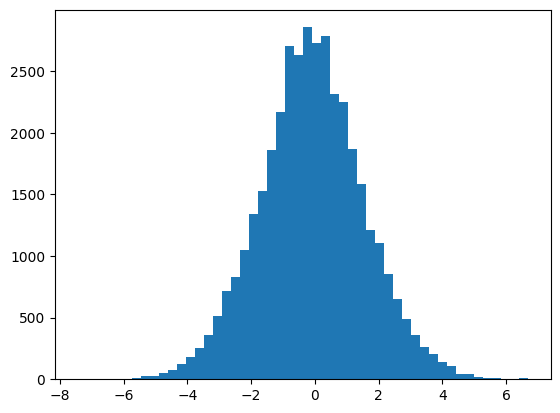

In [353]:
# Distribution of pre-activations
plt.hist(h_preact.view(-1).tolist(), bins=50);
print(h_preact.var())

tensor(3.2244, grad_fn=<VarBackward0>)
tensor(-0.0012, grad_fn=<MeanBackward0>)


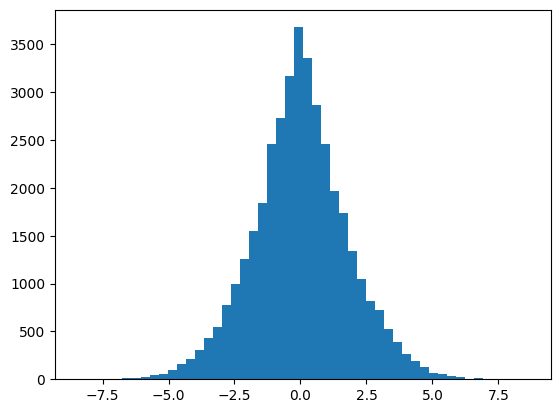

In [357]:
plt.hist(h_norm.view(-1).tolist(), bins=50);
print(h_norm.var())
print(h_norm.mean())

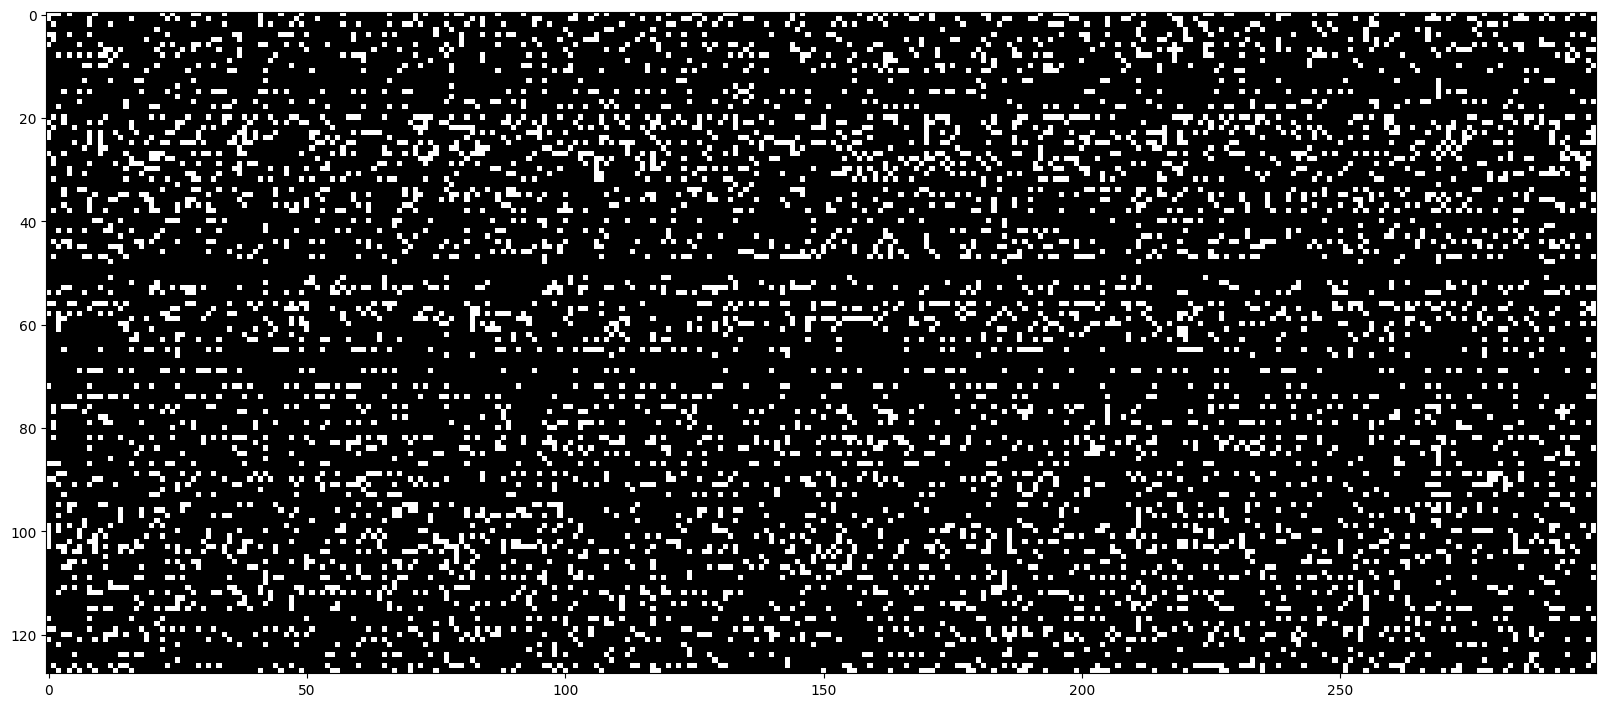

In [358]:
plt.figure(figsize=(20, 10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

tensor(0.5659, grad_fn=<VarBackward0>)


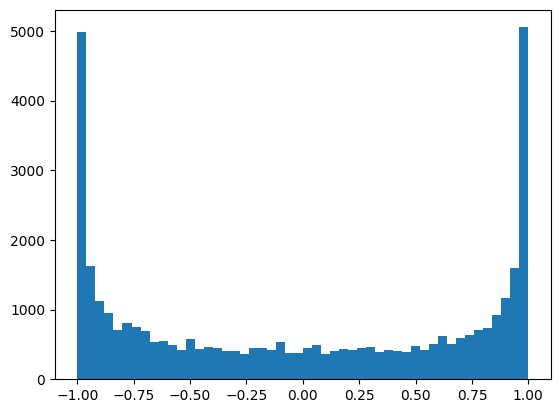

In [359]:
# Distribution of tanh
plt.hist(h.view(-1).tolist(), bins=50);
print(h.var())

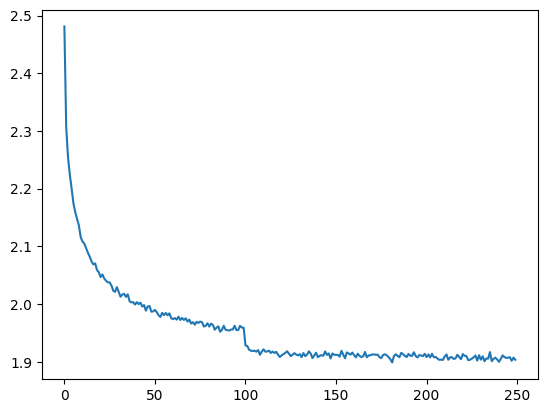

In [360]:
losses = torch.tensor(lossi).view(-1, 1000).mean(1)
plt.plot(losses)

In [361]:
# Val loss
with torch.no_grad():
    X_emb = C[Xdev].reshape(-1, emb_dim * block_size)
    h_preact = X_emb @ W1.T
    h_norm = bngain * ((h_preact - bnmean_running) / bnstd_running) + bnbias
    h = torch.tanh(h_norm)
    logits = h @ W2.T + b2
    loss = F.cross_entropy(logits, ydev)
    print(loss.item())

2.026304244995117


In [362]:
# Test Loss
with torch.no_grad():
    X_emb = C[Xtr].reshape(-1, emb_dim * block_size)
    h_preact = X_emb @ W1.T
    h_norm = bngain * ((h_preact - bnmean_running) / bnstd_running) + bnbias
    h = torch.tanh(h_norm)
    logits = h @ W2.T + b2
    loss = F.cross_entropy(logits, ytr)
    print(loss.item())

1.8866548538208008


In [374]:
for _ in range(15):
    out = []
    context = [0] * block_size
    
    while True:
        h_preact =  C[torch.tensor([context])].view(1, -1) @ W1.T
        h_norm = bngain * ((h_preact - bnmean_running) / bnstd_running) + bnbias
        h = torch.tanh(h_norm)
        logits = h @ W2.T + b2
        counts = logits.exp()
        probs = counts / counts.sum(1, keepdim=True)
        ix = torch.multinomial(probs, num_samples=1, replacement=True).item()
        if ix == 0:
            break
        out.append(itos[ix])

        context = context[1:] + [ix]
    print(''.join(out))

karitha
yarceland
mose
jorie
safviola
kchattilyabelle
rime
rosey
neva
lette
jaa
brickousho
jagen
weslie
elucell
